In [1]:
import logging

%cd /home/ytee/test/trade_bot/



from src.pattern.hmm import HMM


/home/ytee/test/trade_bot/venv/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/home/ytee/test/trade_bot


In [2]:
import itertools

# Assuming get_pnl_all is a method inside a class called StrategyClass
# Replace 'StrategyClass' with your actual class name and make sure it's initialized as 'strategy'

# Define parameter ranges
# diffs_shift_options = [list(comb) for i in range(1, 4)
#                        for comb in itertools.combinations([20, 30, 40, 50], i)]
# diffs_options = [list(comb) for i in range(1, 4)
#                  for comb in itertools.combinations([20, 30, 40, 50], i)]
window_options_main = [list(comb) for i in range(2, 4)
                       for comb in itertools.combinations([100, 200, 300, 400,500], i)]
n_components_options = [2, 3, 4, 5]
train_ratio_options = [0.7]
window_size_options = [300, 400, 500]
crossing_threshold_options = [round(x * 0.1, 1) for x in range(5, 10)]

# Create Cartesian product of all parameters
param_grid = list(itertools.product(
    window_options_main,
    n_components_options,
    train_ratio_options,
    window_size_options,
    crossing_threshold_options
))

print(len(param_grid))
# Fixed options
use_spread = True
use_rank = False
test_only = False


param_grid[0]


1200


([100, 200], 2, 0.7, 300, 0.5)

In [ ]:
from tqdm import tqdm

summary = []
c = HMM()

selected_key = ( 'USD','EUR')
# Iterate through all combinations
for ( window_main,n_components,train_ratio,window_size,crossing_threshold) in tqdm(param_grid):
    
    try:
        # Call the method
        c.re_init(windows=window_main)
        tmp = c.validate_cache_datafile_and_model(
            n_components=n_components,
            train_ratio=train_ratio,
            window_size=window_size,
            use_spread=True,
            crossing_threshold=crossing_threshold
        )

        summary.append(tmp[selected_key])
        # Store results
    except Exception as e:
        print(f"Error for combination: ,  {window_main} , {n_components}, {train_ratio}, {window_size}, {crossing_threshold}" )
        logging.error(f"Error for combination: ,  {window_main} , {n_components}, {train_ratio}, {window_size}, {crossing_threshold}" , exc_info=True)
        

  0%|          | 0/1200 [00:00<?, ?it/s]


In [11]:
('USD','EUR' ) in summary.keys()

True

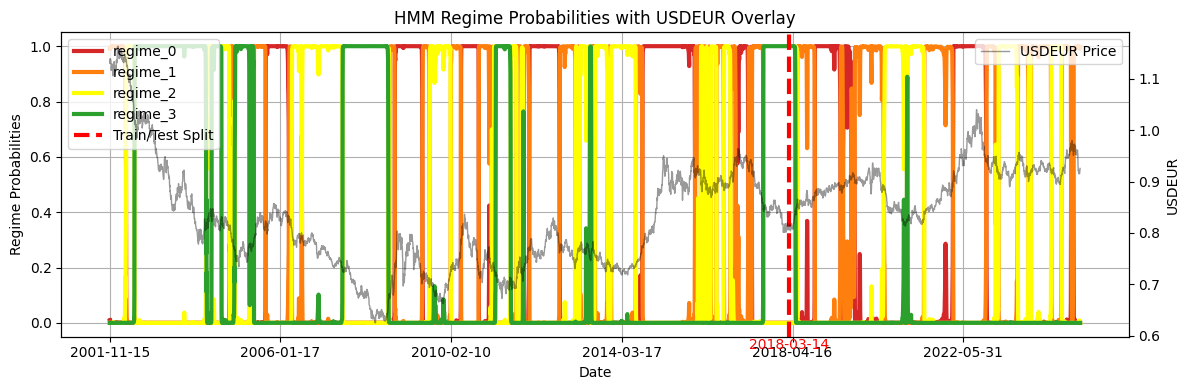

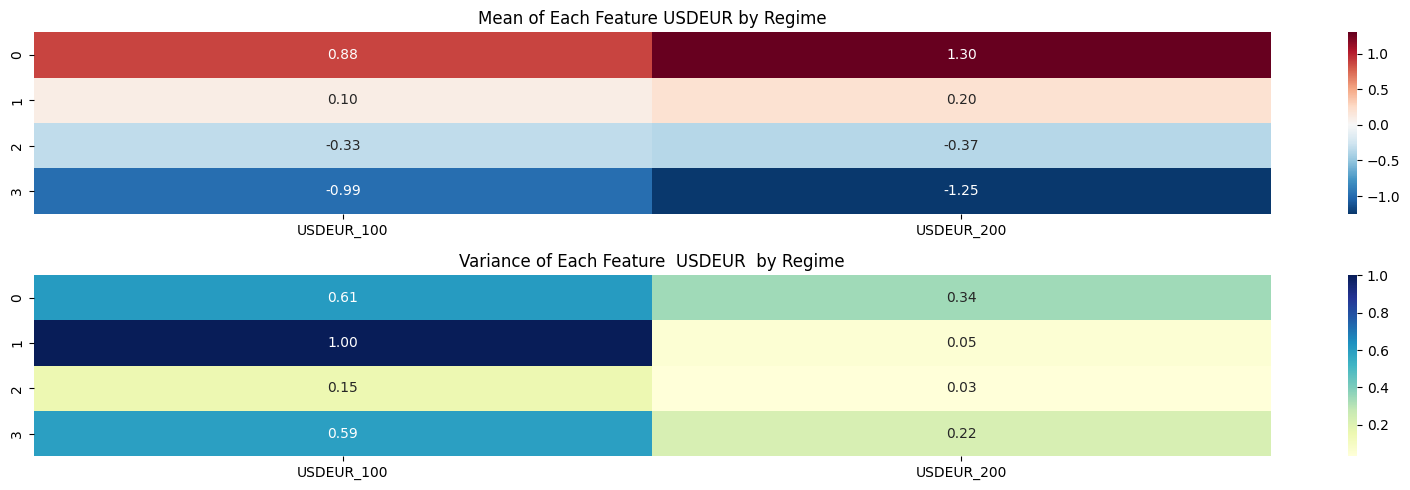

In [27]:

c = HMM()
window_main,n_components,train_ratio,window_size,crossing_threshold = param_grid[0]

c.re_init(windows=window_main)
# c.validate_cache_datafile_and_model(
#     n_components=n_components,
#     train_ratio=train_ratio,
#     window_size=window_size,
#     use_spread=True,
#     crossing_threshold=crossing_threshold
# )
n_components = 4
df =c.get_data(sorted(['EUR' ,'USD']), use_spread=True)
m, probs = c.model(df, n_components=n_components, train_ratio=train_ratio, window_size=window_size, visualize=True)
c.evaluate_model(m, df.columns, visualize=True)
pnl = c.get_pnl(sorted(['EUR', 'USD']), use_spread=True, n_components=n_components, train_ratio=train_ratio, window_size=window_size,
          crossing_threshold=crossing_threshold,)

In [29]:
df

,USDEUR_100,USDEUR_200
index,,
2000.08.22 00:00:00,0.886836,1.551072
2000.08.23 00:00:00,0.842653,1.540343
2000.08.24 00:00:00,0.649977,1.414860
2000.08.25 00:00:00,0.736877,1.382262
2000.08.29 00:00:00,0.784378,1.425695
...,...,...
2025.03.17 00:00:00,-0.018662,0.037299
2025.03.18 00:00:00,-0.055765,0.019939
2025.03.19 00:00:00,0.005302,0.049562


In [ ]:
import pandas as pd
# df_pnl = pd.DataFrame(pnl)
# sign = 1
# if df_pnl.ccy.unique()[0] != 

'EURUSD'

In [8]:
probs

DenseHMM(
  (start): Silent()
  (end): Silent()
  (distributions): ModuleList(
    (0-1): 2 x Normal()
  )
)

In [7]:
import glob
len(glob.glob('/home/ytee3/caches/hmm_cache.cache/*')) /1200

22.938333333333333

In [10]:
window_main,n_components,train_ratio,window_size,crossing_threshold = param_grid[50]
print(param_grid[10])
c.re_init(windows=window_main)

df =c.get_data(use_spread=True)
m= c.model(df, n_components=n_components, train_ratio=train_ratio, window_size=window_size, model_only=True)


([100, 200], 2, 0.7, 500, 0.5)


In [9]:
c.re_init(windows=window_main)
c.validate_cache_datafile_and_model(
    n_components=n_components,
    train_ratio=train_ratio,
    window_size=window_size,
    use_spread=True,
    crossing_threshold=crossing_threshold
)

In [ ]:
c.get_pnl_all(use_spread=True, diffs=[20, 30, 40, 50], n_components=3)

[{'year': '2025',
  'ccy': 'EURUSD',
  'entry_idx': '2025-01-23',
  'exit_idx': None,
  'entry_price': 1.042,
  'exit_price': None,
  'regime': 'regime_1',
  'return': None}]

In [4]:
c= HMM([300, 400])
c.get_pnl_all(use_spread=True, diffs=[20, 30, 40, 50], n_components=3)

In [ ]:
pnl = c.get_pnl(['XAU', 'USD'], train_ratio=0.7,pending=False)
import pandas as pd

df=  pd.DataFrame(pnl)
df.groupby('regime')['return'].sum()

regime
regime_0    0.214642
regime_1   -0.845535
regime_2   -1.085847
Name: return, dtype: float64

2025-05-04 21:15:42,194 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-04 21:15:42,290 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


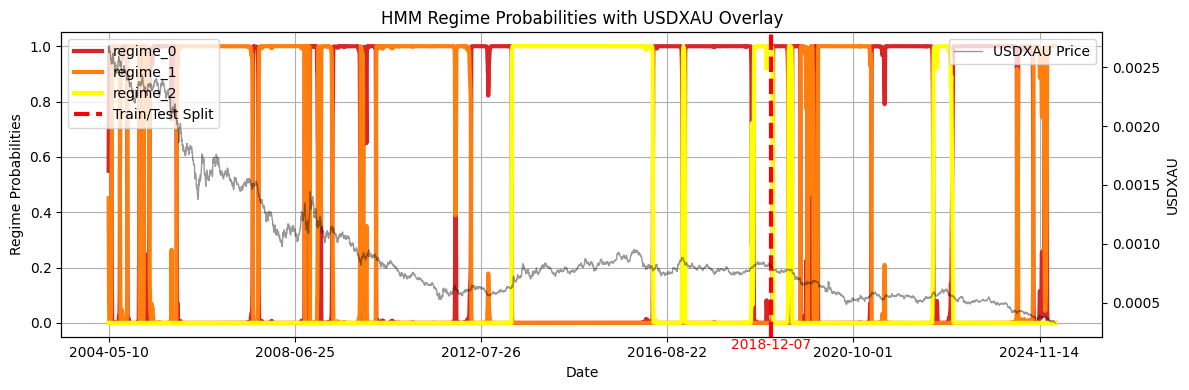

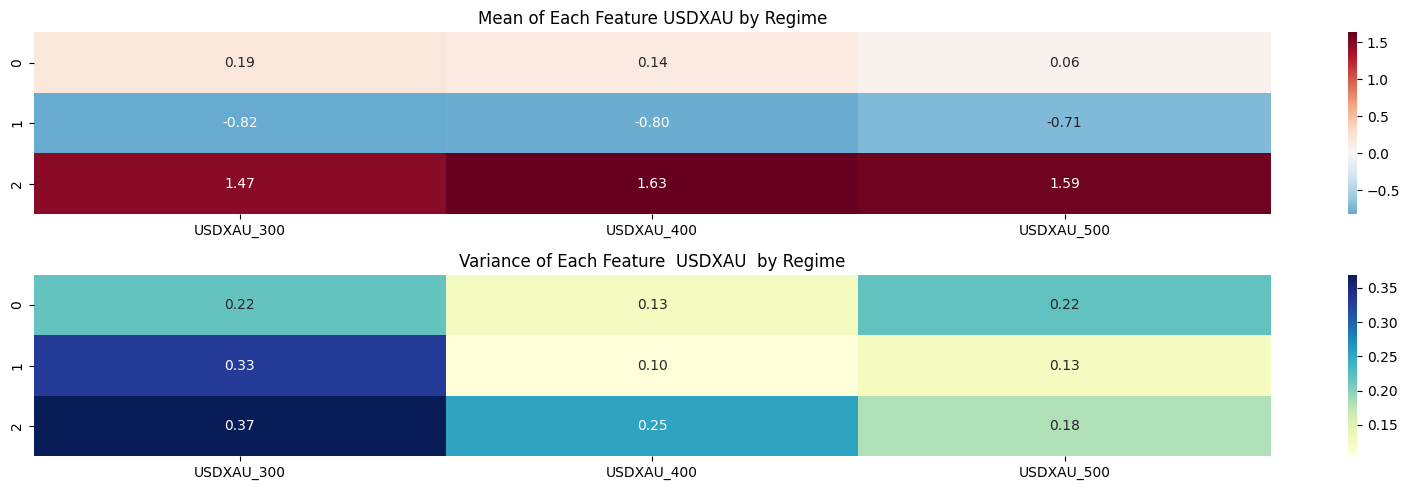

,USDXAU_300,USDXAU_400,USDXAU_500
0,0.186954,0.143225,0.062150
1,-0.819659,-0.801599,-0.705829
2,1.474964,1.631180,1.591405


In [ ]:
c= HMM([300, 400, 500])
df  = c.get_data( ['XAU', 'USD'], use_spread=True)
m, probs= c.model(df, n_components=3, window_size=300, train_ratio=0.7,visualize=True)
c.evaluate_model(m, df.columns,visualize=True)

In [10]:
c._data_cache.keys()

dict_keys(["{'ccy': ['AUD', 'CAD', 'CHF', 'EUR', 'GAS', 'GBP', 'JPY', 'OIL', 'USD', 'XAG', 'XAU'], 'window': [300, 400, 500], 'method': <SMOOTHING_METHOD.ROLLING_ZSCORE: 2>, 'func': 'get_init'}", 'prices', "{'ccy': ['AUD', 'CAD', 'CHF', 'EUR', 'GAS', 'GBP', 'JPY', 'OIL', 'USD', 'XAG', 'XAU'], 'windows': [300, 400, 500], 'pairs': ['CAD', 'XAG'], 'diffs_shift': [], 'diffs': [], 'use_rank': False, 'use_spread': True, 'method': <SMOOTHING_METHOD.ROLLING_ZSCORE: 2>}", "CADXAG_300_CADXAG_400_CADXAG_500{'ccy': ['AUD', 'CAD', 'CHF', 'EUR', 'GAS', 'GBP', 'JPY', 'OIL', 'USD', 'XAG', 'XAU'], 'n_components': 3, 'train_ratio': 0.7, 'window_size': 300, 'method': <SMOOTHING_METHOD.ROLLING_ZSCORE: 2>}", "{'pairs': ['CAD', 'XAG'], 'ccy': ['AUD', 'CAD', 'CHF', 'EUR', 'GAS', 'GBP', 'JPY', 'OIL', 'USD', 'XAG', 'XAU'], 'windows': [300, 400, 500], 'diffs_shift': [], 'diffs': [], 'use_rank': False, 'use_spread': True, 'method': <SMOOTHING_METHOD.ROLLING_ZSCORE: 2>, 'func': 'get_pnl_all', 'n_components': 3, '

2025-05-06 21:05:54,162 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-06 21:05:54,235 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


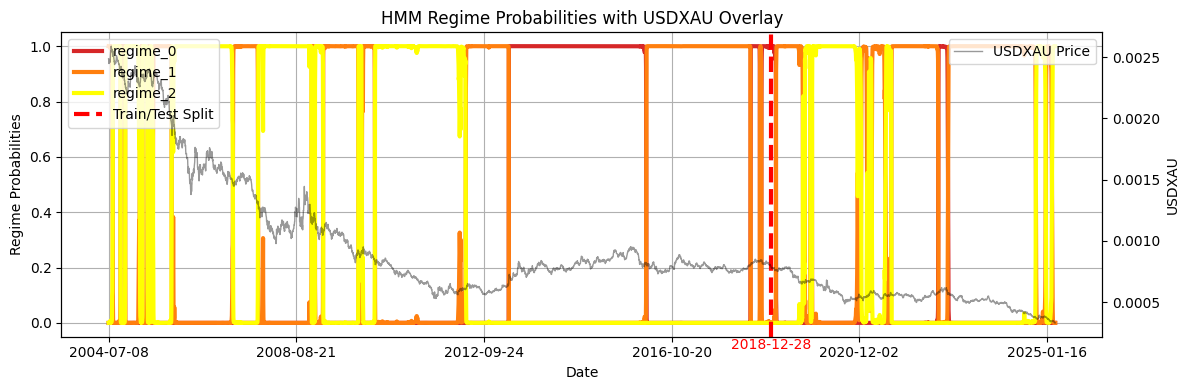

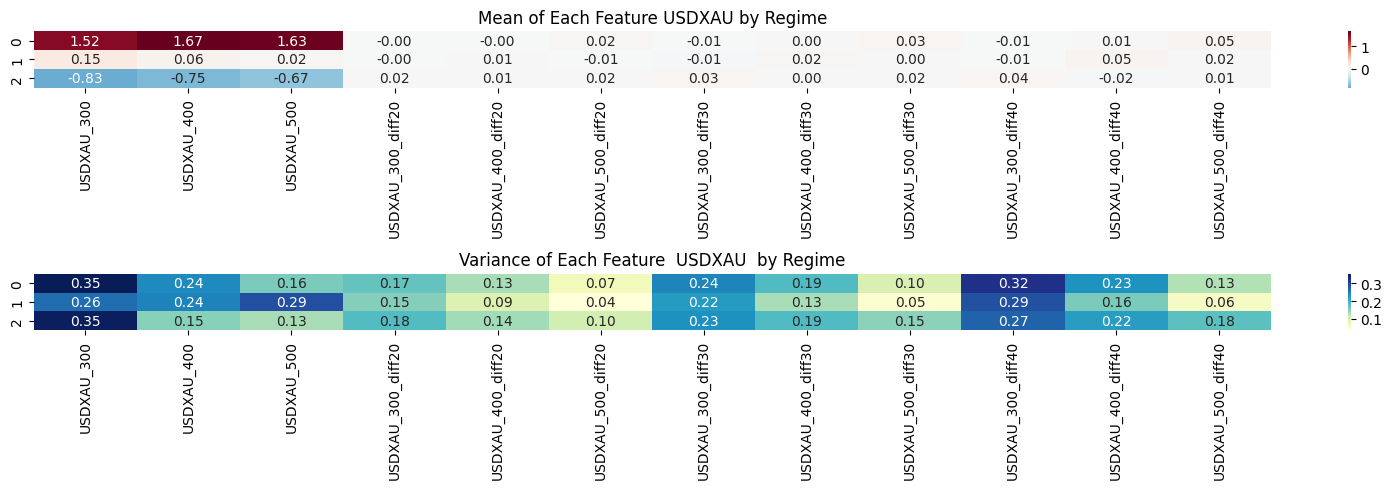

,USDXAU_300,USDXAU_400,USDXAU_500,USDXAU_300_diff20,USDXAU_400_diff20,USDXAU_500_diff20,USDXAU_300_diff30,USDXAU_400_diff30,USDXAU_500_diff30,USDXAU_300_diff40,USDXAU_400_diff40,USDXAU_500_diff40
0,1.518219,1.667355,1.631132,-0.002251,-0.002418,0.020880,-0.007051,0.003449,0.031848,-0.009821,0.012855,0.045565
1,0.151572,0.063635,0.023425,-0.001093,0.012957,-0.005614,-0.011688,0.023935,0.003295,-0.005929,0.048492,0.018399
2,-0.830400,-0.751223,-0.668825,0.015096,0.005647,0.017930,0.033574,0.000229,0.015416,0.035665,-0.019834,0.005497


In [8]:
c= HMM([300, 400, 500])
df  = c.get_data( ['XAU', 'USD'], diffs=[20, 30, 40], use_spread=True)
m, probs= c.model(df, n_components=3, window_size=300, train_ratio=0.7,visualize=True)
c.evaluate_model(m, df.columns,visualize=True)

In [ ]:
opair = c.pairs
invpair = [c.pairs[0][3:] + c.pairs[0][:3]]

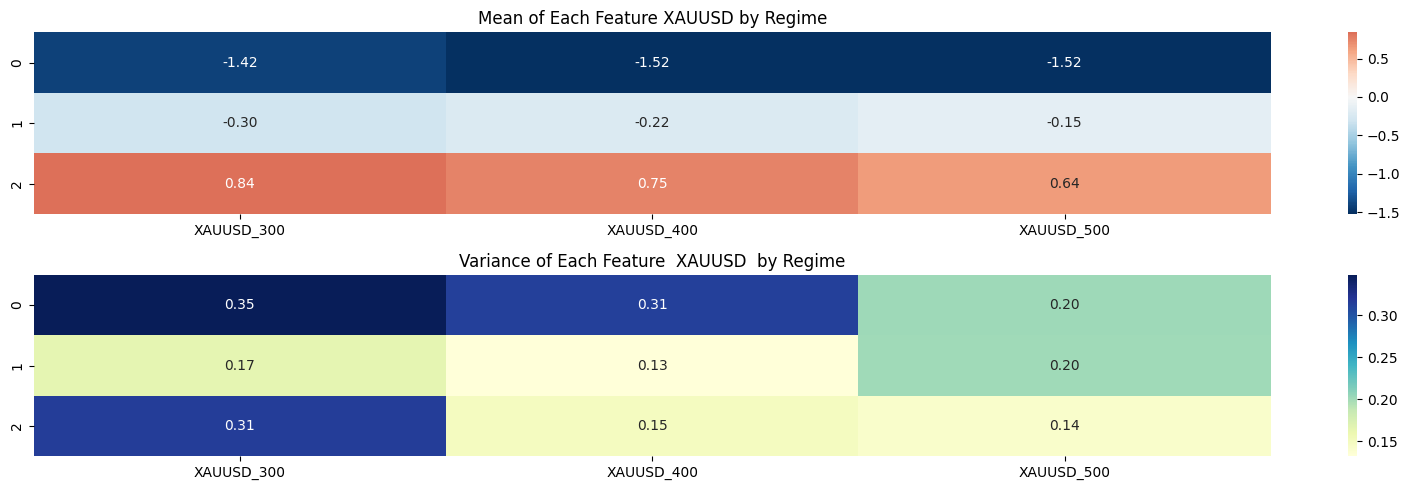

,XAUUSD_300,XAUUSD_400,XAUUSD_500
0,-1.415453,-1.515237,-1.520819
1,-0.296735,-0.222525,-0.145819
2,0.841728,0.746050,0.639097


In [ ]:
c.pairs = invpair
col2 = [x.replace(opair[0], invpair[0]) for x in df.columns]
df2 = df.copy()
df2 = df2*-1
df2.columns = col2
m, probs= c.model(df2, n_components=3, window_size=300, train_ratio=0.8)
c.evaluate_model(m, col2,visualize=True)


In [ ]:
print(probs.head(5))

            regime_0  regime_1  regime_2
2004-07-22  0.000002  0.995433  0.004576
2004-07-23  0.000009  0.964041  0.035974
2004-07-26  0.000010  0.902763  0.097247
2004-07-27  0.000017  0.512749  0.487242
2004-07-28  0.000011  0.053616  0.946377


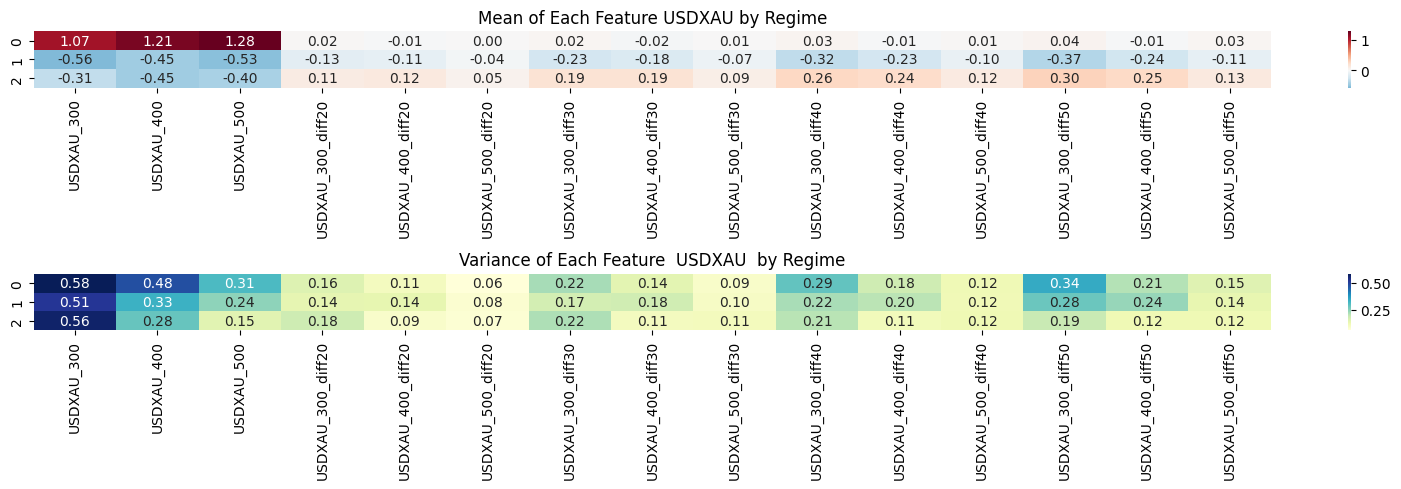

   USDXAU_300  USDXAU_400  USDXAU_500
0    1.071914    1.214148    1.279633
1   -0.561925   -0.453807   -0.531535
2   -0.314770   -0.453374   -0.404003


,USDXAU_300,USDXAU_400,USDXAU_500
0,1.071914,1.214148,1.279633
1,-0.561925,-0.453807,-0.531535
2,-0.314770,-0.453374,-0.404003


In [ ]:
aa = c.evaluate_model(m, df.columns, visualize=True)
bb = aa[[x for x in aa.columns if not 'diff' in x]]
print(bb)

bb

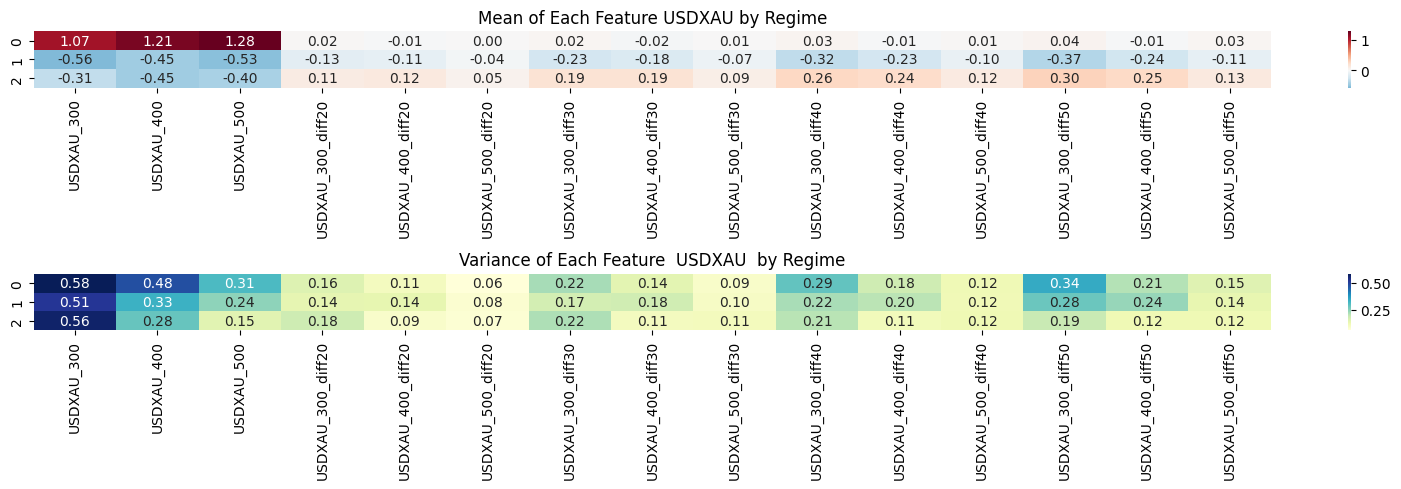

In [ ]:
c.heat_map(m, df.columns)

2019.12.19 00:00:00


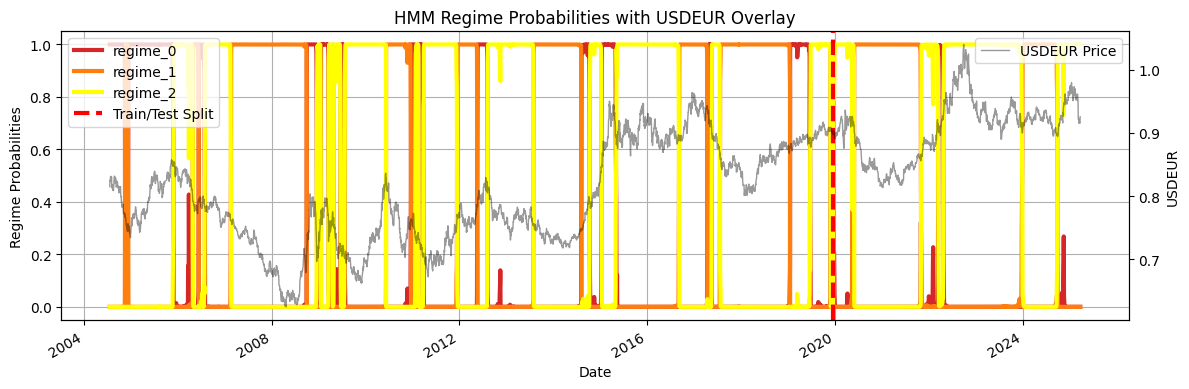

In [ ]:
c= HMM([300, 400, 500])
df  = c.get_data( ['EUR', 'USD'], diffs=[20,30,40,50], use_spread=True)
m= c.plot(df, n_components=3, window_size=300, train_ratio=0.8)

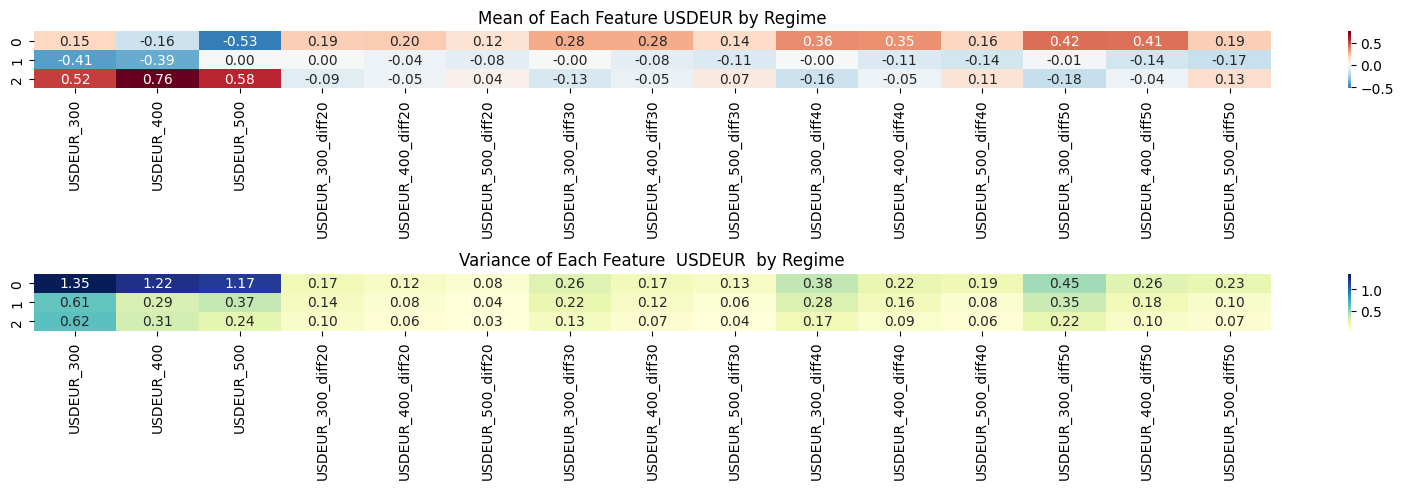

In [ ]:
c.heat_map(m, df.columns)